In [1]:
import sys
import os

project_root = os.path.abspath('..') 

if os.path.join(project_root, 'src') not in sys.path:
    sys.path.append(os.path.join(project_root, 'src'))

from data_loader import load_data
from feature_extraction import extract_power_spectrum
from train_xgboost import calculate_dv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def compute_p1d_from_camels(tau_ds, batch_size):
    nlos, npix = tau_ds.shape
    dv = calculate_dv(L_cMpc_h=25, z=0, n_pixels=npix)

    total_sum = 0.0
    total_cnt = 0

    tau = tau_ds
    F = np.exp(-tau, dtype=np.float64)
    total_sum += F.sum(dtype=np.float64)
    total_cnt += F.size
    Fbar = total_sum / total_cnt

    # Pass 2: accumulate power
    nfreq = npix//2 + 1                      # rfft length
    sum_pk = np.zeros(nfreq, dtype=np.float64)
    counted = 0


    dF = F / Fbar - 1.0

    Fk = np.fft.rfft(dF, axis=1)                 # (m, nfreq)
    Pk_chunk = (np.abs(Fk)**2) * (dv / (npix*dv))  # dv/L_kms with L_kms=npix*dv
    # same as (dv / L_kms); we keep it explicit to show dv/L
    sum_pk += Pk_chunk.sum(axis=0)
    counted += batch_size

    Pk = sum_pk / counted
    k  = 2.0 * np.pi * np.fft.rfftfreq(npix, d=dv)

    # drop DC
    k, Pk = k[1:], Pk[1:]
    Delta2 = (k * Pk) / np.pi

    return k, Delta2

In [3]:
EX1 = "../data/raw/EX1_spectra.hdf5"
EX3 = "../data/raw/EX3_spectra.hdf5"

X, y = load_data(EX1,EX3)
n_pix = X.shape[-1]
dv = calculate_dv(L_cMpc_h=25, z=0, n_pixels=n_pix)
L_kms = dv*n_pix

In [4]:
LOS_per_sim = 10_000
batch_size = 9999

tau_EX1 = X[:batch_size].reshape(1, batch_size*n_pix)
tau_EX3 = X[LOS_per_sim:LOS_per_sim+batch_size].reshape(1, batch_size*n_pix)

flux_EX1, flux_EX3 = np.exp(-tau_EX1), np.exp(-tau_EX3)

In [5]:
k_EX1, Pk_EX1 = compute_p1d_from_camels(tau_EX1, batch_size)
k_EX3, Pk_EX3 = compute_p1d_from_camels(tau_EX1, batch_size)

/opt/miniconda3/envs/lya_ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


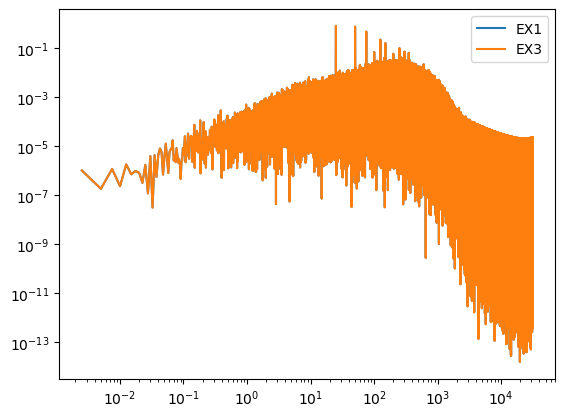

In [6]:
plt.loglog(k_EX1, Pk_EX1, label="EX1")
plt.loglog(k_EX3, Pk_EX3, label="EX3")
plt.legend()
#plt.xlim(1e-3,1e-1)
#plt.ylim(1e-4,1e-2)
plt.show()

[INFO] Processing /Users/antareepgogoi/Codes/lya_forest_ml/data/raw/EX1_spectra.hdf5
(15, 2499)
   -> nlos=15 npix=2499 dv=0.865254 kmin=2.905829e-03 L_kms=2162.27 z=0.0000
[INFO] Processing /Users/antareepgogoi/Codes/lya_forest_ml/data/raw/EX3_spectra.hdf5
(15, 2499)
   -> nlos=15 npix=2499 dv=0.859455 kmin=2.925436e-03 L_kms=2147.78 z=0.0000


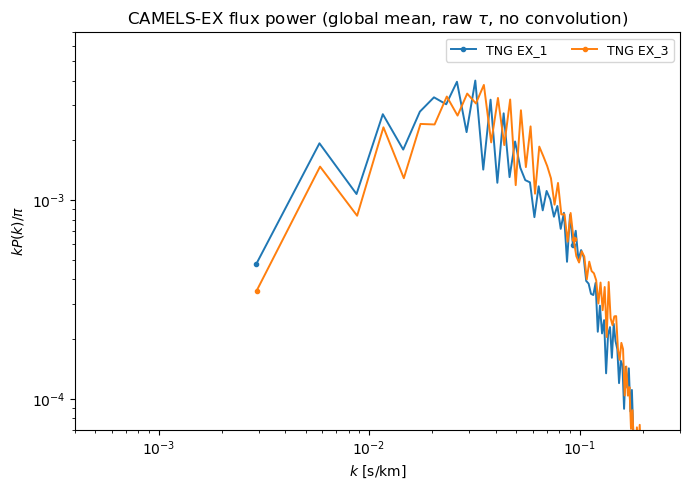

In [9]:
import os, json, math, h5py, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------- CONFIG --------
BASE = "./"
SUITES = {
    "EX_IllustrisTNG": ["EX_1","EX_3"],
}
CHUNK_LOS = 1000        # stream this many sightlines at a time
MEAN_MODE = "global"    # 'global' or 'per_los' (paper comparison typically 'global')
MAKE_PLOT = True

# -------- CORE HELPERS --------
def header_to_Lkms(hdr_attrs, npix):
    """Compute LOS velocity length L_kms and dv from Header."""
    # CAMELS headers: BoxSize (kpc/h), Redshift, HubbleParam (h), Omega0, OmegaLambda
    box_kpch = float(hdr_attrs["box"])
    z        = float(hdr_attrs["redshift"])
    h        = float(hdr_attrs["hubble"])
    om0      = float(hdr_attrs["omegab"])
    omL      = float(hdr_attrs["omegal"])

    L_Mpc    = (box_kpch / 1000.0) / h        # comoving Mpc
    H0       = 100.0 * h                      # km/s/Mpc
    Hz       = H0 * np.sqrt(om0 * (1.0 + z)**3 + omL)
    L_kms    = Hz * L_Mpc / (1.0 + z)
    dv       = L_kms / float(npix)
    return L_kms, dv, z

def compute_p1d_from_camels(path, chunk_los=1000, mean_mode="global", save_outputs=True):
    """
    Returns (k, Delta2) for the file at 'path'.
    Saves .../p1d_global_k.npy and .../p1d_global_Delta2.npy next to the HDF5 by default.
    """
    path = Path(path)
    with h5py.File(path, "r") as f:
        tau_ds = f["/tau/H/1/1215"]                # shape: (N_LOS, N_PIX)
        tau_ds = tau_ds[:15]
        print(tau_ds.shape)
        nlos, npix = tau_ds.shape

        # Try to get L_kms from a velocity axis if present; else compute from Header.
        if "/velocity" in f:  # not always populated as a dataset; be defensive
            # you can extend this to read a real vel axis if the dataset exists
            L_kms, dv, z = header_to_Lkms(f["/Header"].attrs, npix)
        else:
            L_kms, dv, z = header_to_Lkms(f["/Header"].attrs, npix)

        # Pass 1: global mean if requested
        if mean_mode == "global":
            total_sum = 0.0
            total_cnt = 0
            for i0 in range(0, nlos, chunk_los):
                i1 = min(nlos, i0 + chunk_los)
                tau = tau_ds[i0:i1, :]            # (m, npix)
                F = np.exp(-tau, dtype=np.float64)
                total_sum += F.sum(dtype=np.float64)
                total_cnt += F.size
            Fbar = total_sum / total_cnt
        else:
            Fbar = None  # per-lhs handled per chunk

        # Pass 2: accumulate power
        nfreq = npix//2 + 1                      # rfft length
        sum_pk = np.zeros(nfreq, dtype=np.float64)
        counted = 0

        for i0 in range(0, nlos, chunk_los):
            i1 = min(nlos, i0 + chunk_los)
            tau = tau_ds[i0:i1, :]
            F = np.exp(-tau, dtype=np.float64)

            if mean_mode == "global":
                dF = F / Fbar - 1.0
            elif mean_mode == "per_los":
                dF = F / F.mean(axis=1, keepdims=True) - 1.0
            else:
                raise ValueError("mean_mode must be 'global' or 'per_los'")

            Fk = np.fft.rfft(dF, axis=1)                 # (m, nfreq)
            Pk_chunk = (np.abs(Fk)**2) * (dv / (npix*dv))  # dv/L_kms with L_kms=npix*dv
            # same as (dv / L_kms); we keep it explicit to show dv/L
            sum_pk += Pk_chunk.sum(axis=0)
            counted += (i1 - i0)

        Pk = sum_pk / counted
        k  = 2.0 * np.pi * np.fft.rfftfreq(npix, d=dv)

        # drop DC
        k, Pk = k[1:], Pk[1:]
        Delta2 = (k * Pk) / np.pi

    if save_outputs:
        outpref = path.parent / f"p1d_{'global' if mean_mode=='global' else 'perlos'}"
        np.save(str(outpref) + "_k.npy", k)
        np.save(str(outpref) + "_Delta2.npy", Delta2)

    return k, Delta2, dict(nlos=int(nlos), npix=int(npix), dv=float(dv), L_kms=float(npix*dv), z=float(z))

# -------- RUN ALL & PLOT --------
results = []  # list of dicts: suite, ex, k, D2, meta, path
for suite, ex_list in SUITES.items():
    for ex in ex_list:
        if ex == "EX_1":
            h5 = Path("/Users/antareepgogoi/Codes/lya_forest_ml/data/raw/EX1_spectra.hdf5")
        else:
            h5 = Path("/Users/antareepgogoi/Codes/lya_forest_ml/data/raw/EX3_spectra.hdf5")
        if not h5.exists():
            print(f"[WARN] Missing: {h5}")
            continue
        print(f"[INFO] Processing {h5}")
        k, D2, meta = compute_p1d_from_camels(h5, chunk_los=CHUNK_LOS, mean_mode=MEAN_MODE, save_outputs=False)
        results.append(dict(suite=suite, ex=ex, k=k, D2=D2, meta=meta, path=str(h5)))
        print(f"   -> nlos={meta['nlos']} npix={meta['npix']} dv={meta['dv']:.6f} "
              f"kmin={k[0]:.6e} L_kms={meta['L_kms']:.2f} z={meta['z']:.4f}")

if MAKE_PLOT and results:
    plt.figure(figsize=(7,5))
    for r in results:
        label = f"{'TNG' if 'Illustris' in r['suite'] else 'SIMBA'} {r['ex']}"
        # draw sparse markers to help distinguish grids
        step = max(1, len(r['k'])//40)
        plt.loglog(r['k'], r['D2'], label=label, marker='o', markersize=3, markevery=step, linewidth=1.4)
    plt.xlabel(r"$k\ \mathrm{[s/km]}$")
    plt.ylabel(r'$kP(k)/\pi$')
    plt.xlim(4e-4, 3e-1) 
    plt.ylim(7e-5, 7e-3)
    plt.title("CAMELS-EX flux power (global mean, raw $\\tau$, no convolution)")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

EX1 flux shape: (10000, 2499) z = 2.220446049250313e-16
EX3 flux shape: (10000, 2499) z = 2.220446049250313e-16
Running bootstrap...


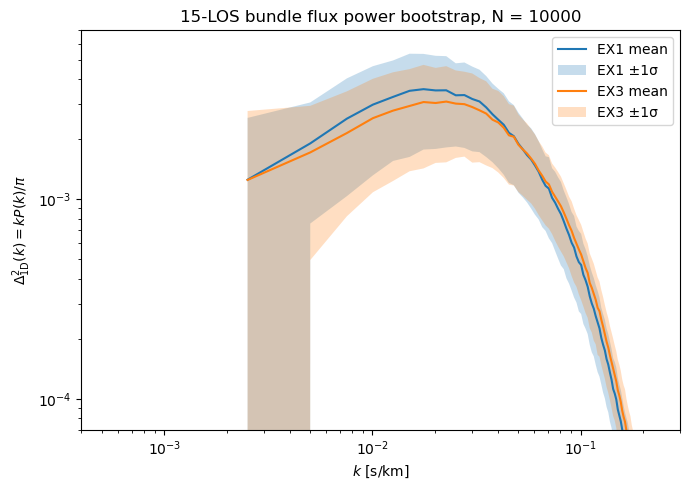

In [13]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# Change paths if needed
# ----------------------------
EX1_PATH = Path("/Users/antareepgogoi/Codes/lya_forest_ml/data/raw/EX1_spectra.hdf5")
EX3_PATH = Path("/Users/antareepgogoi/Codes/lya_forest_ml/data/raw/EX3_spectra.hdf5")

N_BOOT = 10_000
BUNDLE_SIZE = 15
BATCH_SIZE = 200
RNG_SEED = 12345

TAU_KEY = "/tau/H/1/1215"


def get_attr(attrs, names):
    """Try several possible header names."""
    for name in names:
        if name in attrs:
            return float(attrs[name])
    raise KeyError(f"Could not find any of these attributes: {names}")


def get_box_velocity_length_kms(h5file, npix):
    """
    Estimate the velocity length of the simulation box in km/s.
    L_kms = H(z) * L_comoving / (1+z)
    """
    attrs = h5file["/Header"].attrs

    box_kpch = get_attr(attrs, ["box", "BoxSize"])
    z = get_attr(attrs, ["redshift", "Redshift"])
    h = get_attr(attrs, ["hubble", "HubbleParam"])

    # Prefer total matter density. Fall back only if needed.
    try:
        om0 = get_attr(attrs, ["omega0", "Omega0", "OmegaM", "omegam", "Omega_m"])
    except KeyError:
        om0 = get_attr(attrs, ["omegab", "OmegaBaryon"])
        print("Warning: using Omega_b as Omega_m because no total matter density key was found.")

    oml = get_attr(attrs, ["omegal", "OmegaLambda", "Omega_l"])

    L_mpc = (box_kpch / 1000.0) / h
    H0 = 100.0 * h
    Hz = H0 * np.sqrt(om0 * (1 + z)**3 + oml)

    L_kms = Hz * L_mpc / (1 + z)
    dv = L_kms / npix

    return L_kms, dv, z


def load_flux_and_k(path):
    """Load flux array and k grid."""
    with h5py.File(path, "r") as f:
        tau = f[TAU_KEY][:].astype(np.float32)
        nlos, npix = tau.shape
        L_kms, dv, z = get_box_velocity_length_kms(f, npix)

    F = np.exp(-tau, dtype=np.float32)
    k = 2 * np.pi * np.fft.rfftfreq(npix, d=dv)

    # Drop DC mode
    return F, k[1:], dv, z


def bootstrap_bundle_p1d(F, k, dv, n_boot=10000, bundle_size=15, batch_size=200, seed=12345):
    """
    Randomly sample bundles of LOS, compute P1D for each bundle.

    Uses bundle mean normalization:
        delta_F = F / <F>_bundle - 1

    Returns:
        D2_boot: shape (n_boot, nk)
    """
    rng = np.random.default_rng(seed)
    nlos, npix = F.shape
    nk = len(k)

    D2_boot = np.empty((n_boot, nk), dtype=np.float32)

    for start in range(0, n_boot, batch_size):
        end = min(start + batch_size, n_boot)
        nb = end - start

        # Sample 15 distinct LOS per bootstrap bundle
        idx = np.array([
            rng.choice(nlos, size=bundle_size, replace=False)
            for _ in range(nb)
        ])

        bundle = F[idx]  # shape: (nb, bundle_size, npix)

        # Normalize each bundle by its own mean flux
        Fbar = bundle.mean(axis=(1, 2), keepdims=True)
        dF = bundle / Fbar - 1.0

        # FFT each LOS, then average Pk over the 15 LOS in the bundle
        Fk = np.fft.rfft(dF, axis=2)
        Pk_los = (dv / npix) * np.abs(Fk)**2
        Pk_bundle = Pk_los.mean(axis=1)

        # Drop DC mode and convert to Delta^2 = k P(k) / pi
        Pk_bundle = Pk_bundle[:, 1:]
        D2_boot[start:end] = (k[None, :] * Pk_bundle / np.pi).astype(np.float32)

    return D2_boot


# ----------------------------
# Run
# ----------------------------
F1, k1, dv1, z1 = load_flux_and_k(EX1_PATH)
F3, k3, dv3, z3 = load_flux_and_k(EX3_PATH)

assert np.allclose(k1, k3), "EX1 and EX3 k grids do not match."
k = k1

print("EX1 flux shape:", F1.shape, "z =", z1)
print("EX3 flux shape:", F3.shape, "z =", z3)
print("Running bootstrap...")

D2_EX1 = bootstrap_bundle_p1d(F1, k, dv1, N_BOOT, BUNDLE_SIZE, BATCH_SIZE, RNG_SEED)
D2_EX3 = bootstrap_bundle_p1d(F3, k, dv3, N_BOOT, BUNDLE_SIZE, BATCH_SIZE, RNG_SEED + 1)

mean1, sig1 = D2_EX1.mean(axis=0), D2_EX1.std(axis=0)
mean3, sig3 = D2_EX3.mean(axis=0), D2_EX3.std(axis=0)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(7, 5))

plt.loglog(k, mean1, label="EX1 mean")
plt.fill_between(k, mean1 - sig1, mean1 + sig1, alpha=0.25, label="EX1 ±1σ")

plt.loglog(k, mean3, label="EX3 mean")
plt.fill_between(k, mean3 - sig3, mean3 + sig3, alpha=0.25, label="EX3 ±1σ")

plt.xlabel(r"$k\ [{\rm s/km}]$")
plt.ylabel(r"$\Delta^2_{\rm 1D}(k) = kP(k)/\pi$")
plt.title(f"15-LOS bundle flux power bootstrap, N = {N_BOOT}")
plt.xlim(4e-4, 3e-1)
plt.ylim(7e-5, 7e-3)
plt.legend()
plt.tight_layout()
plt.show()